# This notebook will introduce you to understand the elements within an energy balance model of the Earth system and apply a simple approach to quantify how changes in absorbed shortwave radiation (ASR), atmospheric emissivity, and albedo impact Earth’s surface temperature

 __Author__: Sara Grisales-Vargas. For any questions regarding the contents of this notebook please contact sara.grisales.vargas@temple.edu

## Datasets used in this notebook:

### **Simulated change in global average surface air temperature** from NASA GISS ModelE2 developed as NASA’s Goddard Institute for Space Studies (*NASA_GISS_Response_To_Forcings.csv*)
 *  Units: Kelvin

### **Observed change in global average surface air temperature** for comparison to 
model result (*Observed_Temps.csv*)
 *  Units: Kelvin

### **Annual-mean Total Solar Irradiance (TSI)** reconstruction based on the 
“Community-Consensus TSI Composite” (Dudok de Wit et al., GRL, 2017) and 
SATIRE-T model (Wu et al,
A&A, 2018). Computed by Greg Kopp using 'Community-Consensus TI 
ComposiLINK HERE te. (https://spot.colorado.edu/~koppg/T
 *  Units:nits <sup> :  </sup>W m-2s

In [1]:
# import our packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd                          

In [2]:
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 12,6   

### The temperature of the Earth is affected by the amount of energy coming from the Sun and the amount of energy reflected away from the Earth into space. To explore the influence of the Sun in Earth's climate system we can rely on different physical principles:
* The conservation of energy: the amount of energy leaving Earth exactly balances the amount of incoming energy from sunlight (Energy in=Energy out)
* The concept of a blackbody object (A blackbody absorbs and emits radiation at all wavelengths) and Wein’s law that relates temperature and wavelength of radiation emitted by a blackbody object.
* The Stefan-Boltzmann’s law to estimate the total energy emitted from an object and the object's temperature

Source: https://scied.ucar.edu/interactive/albedo-brightness

![image](https://www.calacademy.org/sites/default/files/styles/manual_crop_standard_960x540/public/uploads/images/earthsdelicateenergybalance-energyinenergyout1200x900.png?itok=6I9nqNsD&c=4874a7bbdf86685ab5d0739c7f1896c1)

<center> Source: https://www.calacademy.org/educators/earths-delicate-energy-balance </center>

# Estimation of Earth's surface temperature based on a simple energy balance

Define the variables needed to estimate the Earth's surface temperature

In [3]:
earth_rad =  6378137              # Earth's radius in meters
sun_rad = 696000000               # Sun's radius in meters
d_earth =  149600000000           # Distance of the Earth from the Sun in meters
sigma = 5.67e-8                   # Stefan-Boltzman constant W⋅m−2⋅K−4
epsilon = 1                       # Emissivity for a blackbody - unitliess
T_sun =  5778                     # Sun's average surface temperature in Kelvin
alpha = 0.3                       # Earth's average albedo

In [7]:
energy_flux_sun = epsilon * sigma * (T_sun)**4          #Total energy flux leaving the sun
Q_sun = energy_flux_sun * (4 * np.pi * (sun_rad ** 2))  #Total energy radiating from the sun
S_constant = Q_sun / (4 * np.pi * (d_earth ** 2))       #Solar irradiance
Esun_incident = S_constant*(np.pi*earth_rad**2)         #Incident radiation

## Absorbed shortwave radiation (ASR)

$$
Energy_{in} = (1 - \alpha)S_{0}\pi R_{earth}^2
$$

In [8]:
Energy_in = Esun_incident - alpha * S_constant * np.pi * (earth_rad **2)
Energy_in

1.223725755897003e+17

## Earth's surface temperature (T$_{earth}$):

$$
T_{earth} = \sqrt[4]{\frac{(1 - \alpha) S_{0}}{4 \epsilon \sigma}}
$$

* Energy is measured in $W/ m^{2}$

* $\alpha$ = Surface albedo

* $\epsilon$ = emissivity, is an estimate of how much energy an object can absorb and release. For a blackbody object, emissivity is 1.

* $\sigma$ = Stefan Boltzmann's constant

* Temperature is measured in Kelvin

* Solar constant or solar irradiance ($ S_{0}$): Total energy radiating from the Sun that reaches the Earth ($W/ m^{2}$). This is the intensity of solar radiation as it enters Earth's atmosphere. 

> This model has one extreme simplification - it assumes Earth has **no atmosphere!** 

### Earth's temperature is in function of:
#### Albedo ($ \alpha$)

The amount of solar radiation reflected into space from the Earth's surface. It ranges from 0 to 1, where alpha = 0 represents 0% reflected energy, meaning all energy is absorbed. Alpha = 1 means all (100%) energy is reflected.

The lower the albedo, the more solar radiation is absorbed by the planet. Light surfaces like snow, have a higher albedo, reflecting more energy. Dark surfaces, like the ocean, have a low albedo, reflecting less energy. Overall, Earth's average albedo is about 30% (Kostrykin et al., 2021)

![image]( https://scied.ucar.edu/sites/default/files/media/images/earth_colors.jpg)

Source: https://scied.ucar.edu/learning-zone/how-climate-works/albedo-and-climate


<center> Table 1. Approximate albedo values for different surfaces </center>

| Surface |	Albedo | 
| --- | --- |
| Forest | 0.15 |
| Fresh snow | 0.90 |
| Earth’s planetary albedo | 0.3 |
| Ocean | 0.06 |
| Sea ice |	0.5 – 0.7 |

<center>Sources: https://nsidc.org/learn/parts-cryosphere/sea-ice/science-sea-ice, https://scied.ucar.edu/learning-zone/how-climate-works/albedo-and-climate</center>

## For a solar irradiance of 1367.88 $ W/{m}^2 $, albedo of 30% and emissivity 1, the calculated <span style = "color: red">Earth’s temperature is 254.90 K (-18.25°C)</span>. When we assume a planet without atmosphere and greenhouse gases, the Earth would be a rock of ice, making it inhabitable for life as we know it.

In [9]:
T_earth = ( ((1- alpha)*S_constant)/(4*epsilon*sigma) ) ** 0.25
T_earth, T_earth-273.15

(254.90354346227977, -18.246456537720206)

# The Sun's energy is an essential part of the Earth’s climate system.

![Image]( https://www.worldatlas.com/r/w1300/upload/4d/95/ce/cda8298a-8220-4e83-8c15-969110c6713d.jpeg)Source: https://www.worldatlas.com/space/how-far-away-is-the-sun.html

### <span style = "color: red">1</span>

### **Total solar irradiance (TSI)**
It is the radiant energy from the Sun incident at the top of the Earth’s atmosphere. It is the Earth's dominant energy input. The TSI observational records indicate that Sun’s total radiant energy varies with time, with an average value of 1361 $W/ m^{2}$ from 1610 to 2018 (Kopp et al., 2016).

In [10]:
#Define home working directory
ees_climate_dir = 'C:/Users/TU_Climate24_Student/Desktop/ees_climate/'  #### This is the home directory we are always working out of

#Load TSI dataset
solar_constant_data = pd.read_csv("https://spot.colorado.edu/~koppg/TSI/Historical_TSI_Reconstruction.txt", 
                                  skiprows=6, sep=' ').rename(columns={';':'year', 'Year':'NaN', 'Unnamed: 2':'NaN2',
                                                                       'Unnamed: 3':'NaN3', 'TSI':'NaN4',
                                                                       '[W/m^2]':'TSI [W/m^2]'})

Display the first five rows of each dataset to explore their structure

In [11]:
solar_constant_data.head(5)

,year,NaN,NaN2,NaN3,NaN4,TSI [W/m^2]
0,1610.5,NaN,NaN,NaN,NaN,1360.1856
1,1611.5,NaN,NaN,NaN,NaN,1360.4700
2,1612.5,NaN,NaN,NaN,NaN,1360.6798
3,1613.5,NaN,NaN,NaN,NaN,1360.9569
4,1614.5,NaN,NaN,NaN,NaN,1361.0877


In [12]:
solar_constant_data['year'].min(), solar_constant_data['year'].max()

(1610.5, 2018.5)

In [13]:
solar_constant_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         409 non-null    float64
 1   NaN          0 non-null      float64
 2   NaN2         0 non-null      float64
 3   NaN3         0 non-null      float64
 4   NaN4         0 non-null      float64
 5   TSI [W/m^2]  409 non-null    float64
dtypes: float64(6)
memory usage: 19.3 KB


In [14]:
# Transform the column 'year' from float to integer
solar_constant_data.year = solar_constant_data.year.astype(int)
solar_constant_data.head(5)

,year,NaN,NaN2,NaN3,NaN4,TSI [W/m^2]
0,1610,NaN,NaN,NaN,NaN,1360.1856
1,1611,NaN,NaN,NaN,NaN,1360.4700
2,1612,NaN,NaN,NaN,NaN,1360.6798
3,1613,NaN,NaN,NaN,NaN,1360.9569
4,1614,NaN,NaN,NaN,NaN,1361.0877


### <span style = "color: red">2</span>
#### The **Solar Constant ($S_0$)** is approximated as constant in our energy budget calculations, however observational records do indicate that it varies in time. From 1610 to 2018 the mean and the magnitude of the interannual variability is 1360.98 $+-$ 0.47 $W/{m}^2$

In [18]:
print("TSI mean:",solar_constant_data['TSI [W/m^2]'].mean(), ", TSI magnitude:", solar_constant_data['TSI [W/m^2]'].std())

TSI mean: 1360.9803982885085 , TSI magnitude: 0.4736141972795096


### <span style = "color: red">3</span>

Text(0.5, 0, 'Year')

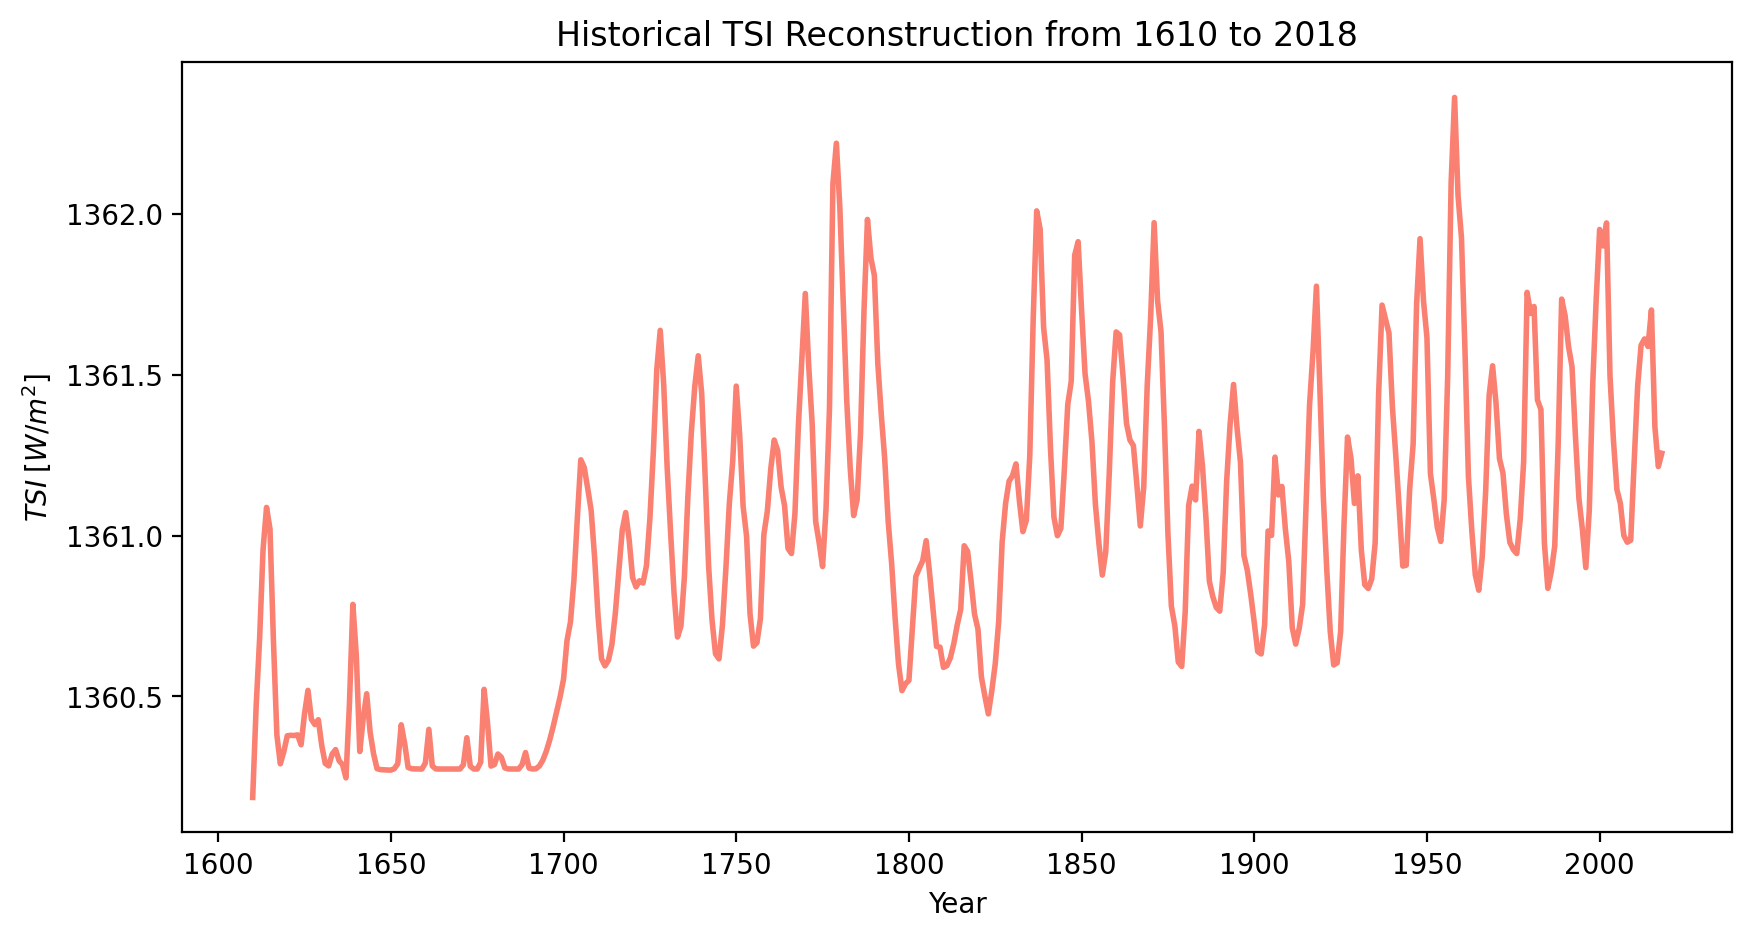

In [16]:
fig, ax = plt.subplots(figsize = (10, 5))

### add the GISS temp dataset to the plot first:
ax.plot(solar_constant_data['year'],
        solar_constant_data['TSI [W/m^2]'],
        linewidth=2,
        color='salmon')

## add plot title:
ax.set_title('Historical TSI Reconstruction from 1610 to 2018')

## add axes labes:
ax.set_ylabel(r'$ TSI_ [W/ m^{2}]$') #
ax.set_xlabel('Year')

Figure 1. Historical TSI reconstruction since 1610 to 2018 based on 'Community-Consensus TSI Composite' (Dudok de Wit et al., GRL, 2017) and SATIRE-T model (Wu et al., A&A, 2018)

### <span style = "color: red">4 & 5</span>


These historical reconstructions of Total Solar Irradiance, estimated from sunspot observations, reveal some of the 11-year solar cycles more active than others (Kopp et al., 2016). For example, between 1645-1715, the Sun went through a 70-year quiet period known as the <span style = "color: red">**Maunder Minimum**</span>. Sunspots disappeared almost completely, and the solar wind was maybe half of its modern velocity. The Maunder Minimum partially overlapped a centuries-long cold spell called the Little Ice Age, which was strongest in the Northern Hemisphere between 1450 and ­1850 (Coddington et al., 2016). 

In [25]:
#Find the row number of the first year from the Maunder Minimum period (source: https://stackoverflow.com/questions/38185688/select-rows-containing-certain-values-from-pandas-dataframe)
solar_constant_data[solar_constant_data.values == 1645] 

,year,NaN,NaN2,NaN3,NaN4,TSI [W/m^2]
35,1645,NaN,NaN,NaN,NaN,1360.3211


In [26]:
#Find the row number of the final year from the Maunder Minimum period (source: https://stackoverflow.com/questions/38185688/select-rows-containing-certain-values-from-pandas-dataframe)
solar_constant_data[solar_constant_data.values == 1715] 

,year,NaN,NaN2,NaN3,NaN4,TSI [W/m^2]
105,1715,NaN,NaN,NaN,NaN,1360.7589


In [36]:
#Get the average within the Maunder Minium period with information available (1645 - 1715)
Maunder_Minimum_S0 = solar_constant_data['TSI [W/m^2]'].loc[35:105].mean()
Maunder_Minimum_S0

1360.4281169014087

### Function to estimate the Earth's surface temperature based on a simple energy balcance model of the Earth System

In [34]:
def earth_surface_temp(albedo = alpha,S0 = S_constant, emissivity = epsilon):
    """ 
    This function estimates the Earth's surface temperature using a simple
    energy balance model of the Earth System.
    
    Parameters
    ----------
    input : albedo (float). The default value is alpha
    input : S0 (float). The default value is S_constant
    input : emissivity (float). The default value is epsilon
    
    Returns
    -------
    output: temp_earth (float) in Kelvin    
    """

    Esun_incident = S0*(np.pi*earth_rad**2)
    Energy_in = Esun_incident - albedo * S0 * np.pi * (earth_rad **2)
    temp_earth = ( ((1- albedo)*S0)/(4*emissivity*sigma) ) ** 0.25
    
    return temp_earth

#### Earth's surface temperature assuming:
 * ##### Average Earth's albedo
 * ##### Solar constant estimated from the Inverse Square Law
 * ##### Emissivity from a black body object

In [35]:
print(np.round_(earth_surface_temp(),2),'K')

254.9 K


If we use the TSI values estimated during the Maunder Minimum period (TSI 1645 - 1715) in our energy budget model, ignoring greenhouse gases and with constant albedo, the **Earth’s temperature reaches its lowest value of 254.56 K ( -18.59°C)**, as seen in the cells below.

In [39]:
print(np.round_(earth_surface_temp(S0 = Maunder_Minimum_S0),2),'K,',np.round_(earth_surface_temp(S0 = Maunder_Minimum_S0)-273.15,2),'°C')

254.56 K, -18.59 °C


### <span style = "color: red">6</span>

### Evaluating the Earth's temperature with Changes in $ S_{0} $ and therefore in ASR

In order to observe the Earth’s temperature variations caused by changes in the TSI observational record, we can create a function to estimate Earth’s temperature using the energy budget model with the values of albedo, emissivity and $S_0$ constant by default, but allowing changes to each parameter.

In [40]:
earth_surface_temp(S0 = solar_constant_data['TSI [W/m^2]'])

0      254.544250
1      254.557554
2      254.567368
3      254.580327
4      254.586444
          ...    
404    254.609845
405    254.615151
406    254.598166
407    254.592382
408    254.594313
Name: TSI [W/m^2], Length: 409, dtype: float64

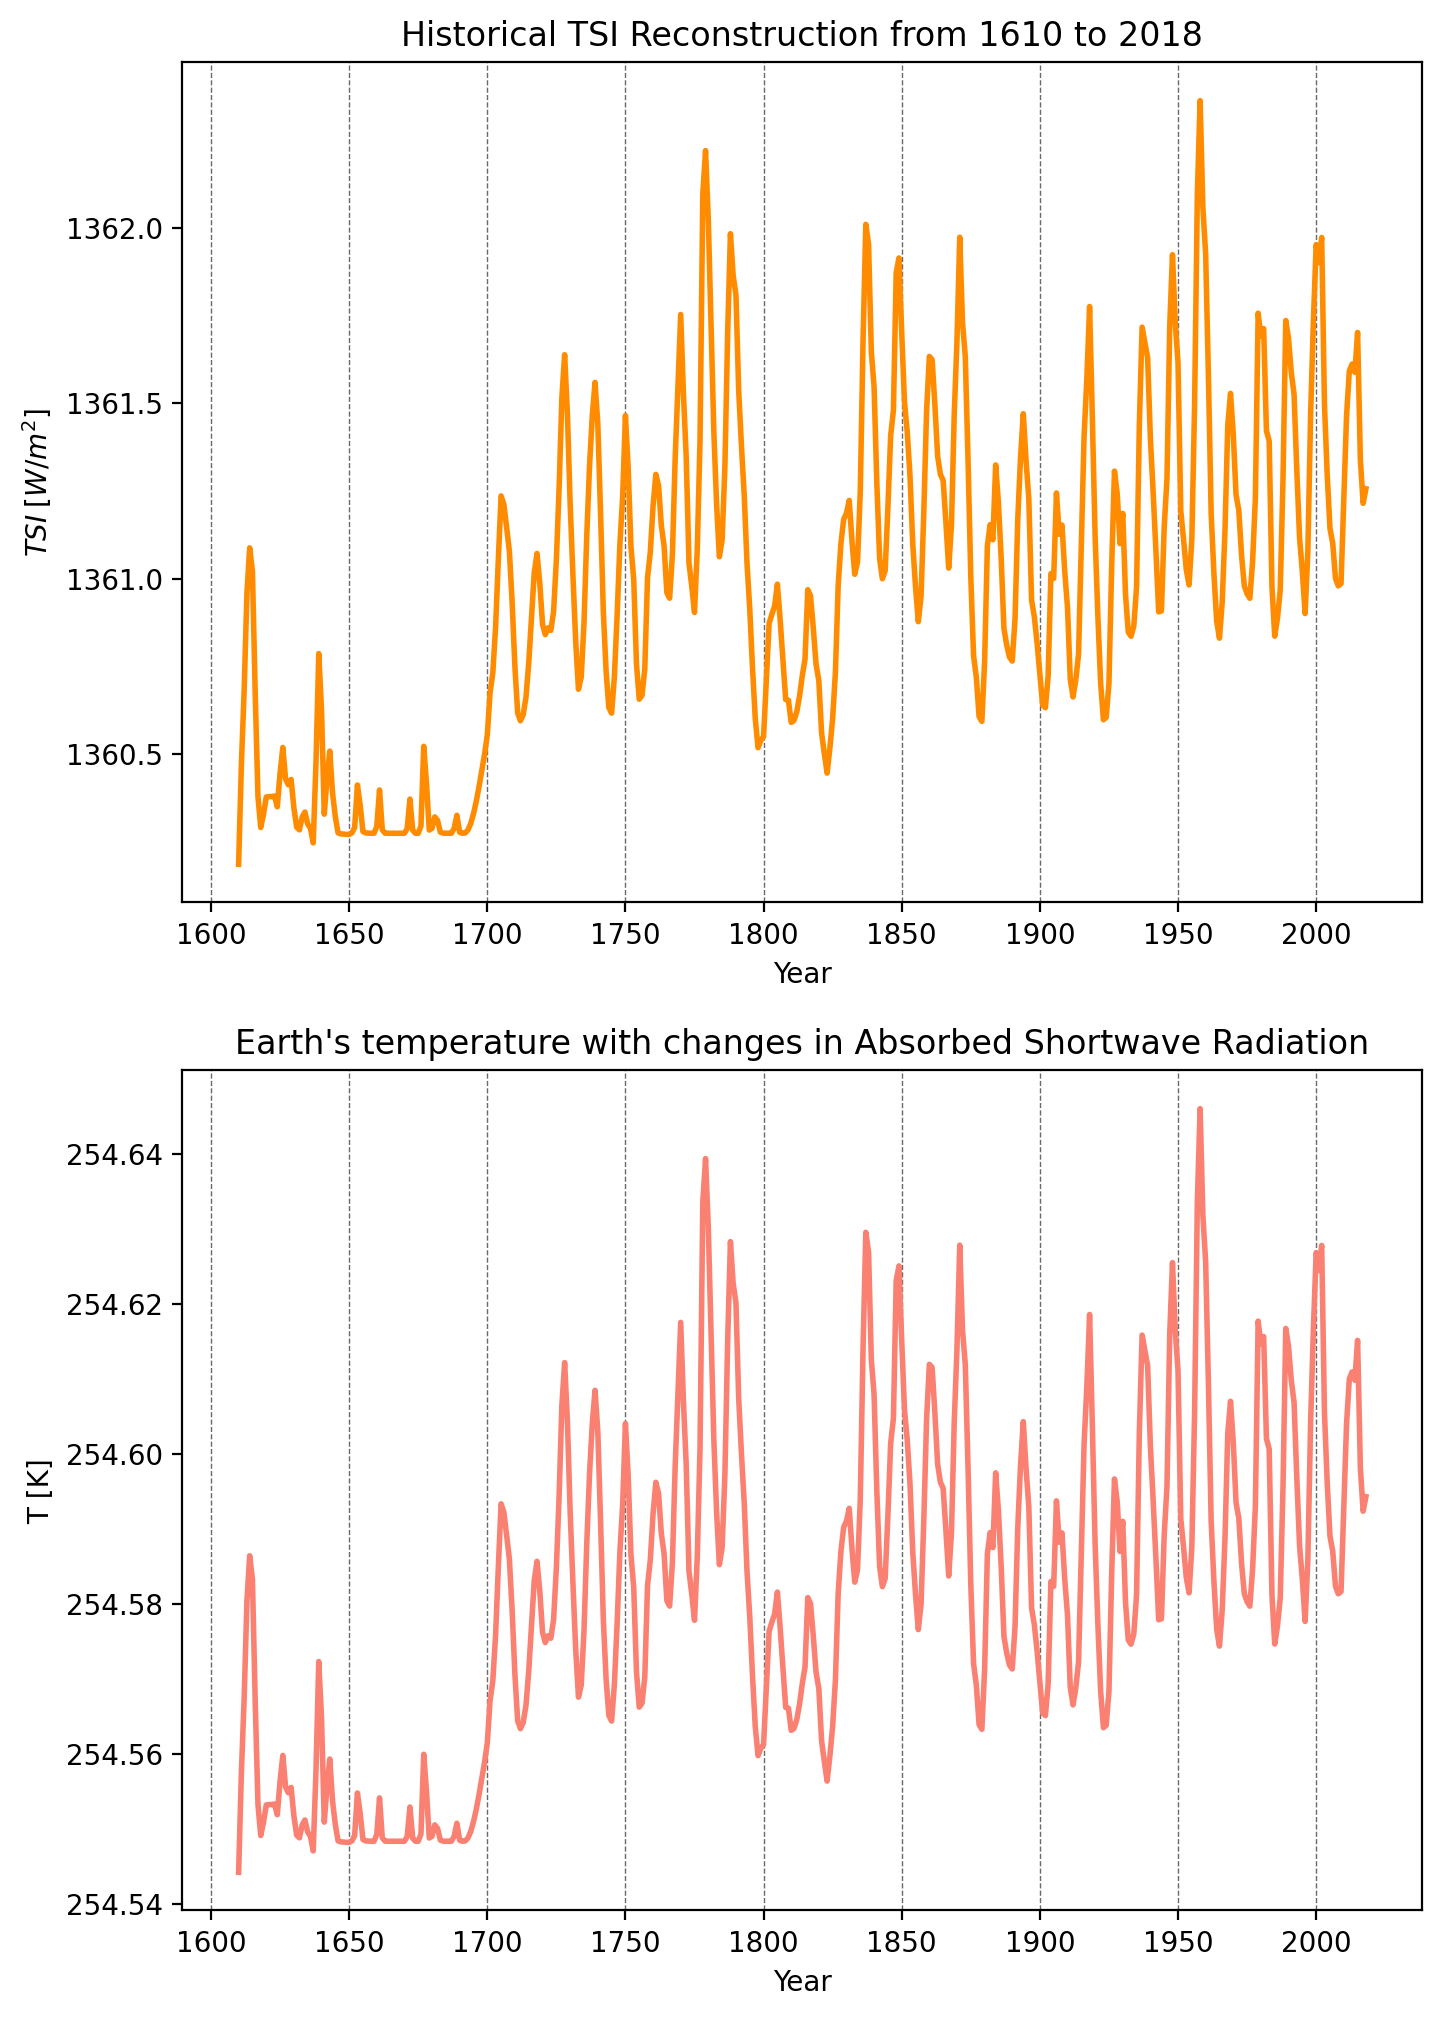

In [42]:
# Figure with three plots down one column
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 12))

### add the GISS temp dataset to the plot first:
ax1.plot(solar_constant_data['year'],
        solar_constant_data['TSI [W/m^2]'],
        linewidth=2,
        color='darkorange')

## add plot title:
ax1.set_title('Historical TSI Reconstruction from 1610 to 2018')

## add axes labes:
ax1.set_ylabel(r'$ TSI_ [W/ m^{2}]$')
ax1.set_xlabel('Year')
#Add vertical grid 
ax1.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

### add the Earth's surface temperature from the original model to the plot first:
ax2.plot(solar_constant_data['year'],
        earth_surface_temp(S0 = solar_constant_data['TSI [W/m^2]']),
        linewidth=2,
        color='salmon')

## add plot title:
ax2.set_title("Earth's temperature with changes in Absorbed Shortwave Radiation")

## add axes labes:
ax2.set_ylabel('T [K]')
ax2.set_xlabel('Year')
#Add vertical grid 
ax2.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

#Save image in working directory
#fig.savefig('TSI_Tearth.png')

Figure 2. Observational record of Total Solar Irradiance (TSI) $[W/ m^{2}]$ (top graph) and estimated global average temperature of Earth, assuming albedo and emissivity constant from 1610 to 2018 (lower graph)

### <span style = "color: red">7</span>

Using the TSI reconstruction data, we can estimate the Earth’s temperature assuming albedo and emissivity are constant. The top graph in **Figure 2** shows the historical TSI from 1610 to 2018. In the lower graph the natural fluctuations in Earth’s temperature are shown. Although small in magnitude (changes of 0.10 K), these temperature variations follow the pattern of changes in the Sun’s energy, with a **percentage variability of 0.035%**, highlighting the role of solar irradiance influencing Earth’s temperature. 

In [44]:
#Percentage of variability std/mean*100
(solar_constant_data['TSI [W/m^2]'].std()/solar_constant_data['TSI [W/m^2]'].mean()) * 100

0.03479948703707268

In [145]:
np.round(solar_constant_data['TSI [W/m^2]'].mean(),2), np.round(earth_surface_temp(S0 = solar_constant_data['TSI [W/m^2]']).mean(),2)

(1360.98, 254.58)

In [146]:
np.round(solar_constant_data['TSI [W/m^2]'].std(),2), np.round(earth_surface_temp(S0 = solar_constant_data['TSI [W/m^2]']).std(),2)

(0.47, 0.02)

<center>Table 2. Total Solar Irradiance and Earth's average global mean surface temperature</center>

| Statistic  | TSI $[W/ m^{2}]$  | Earth's Surface Temperature [K] | 
| --- | --- | --- | 
| Mean | 1360.98 | 254.58 |  
| Standard deviation | 0.47 | 0.02 | 


### <span style = "color: red">8</span>

### Evaluating the Earth's temperature with changes in albedo ($ \alpha$)

Even small variations in solar irradiance can produce natural responses in Earth’s climate. We can explore how surface changes affect the energy balance and the overall climate system by changing other parameters of the model and evaluate the response in the Earth’s temperature.

To understand the role of albedo in the Earth’s climate system we will assume the other input parameters to be constant (solar irradiance and emissivity). As albedo can take values from 0 to 1, we can create a sequence from 0 to 1 to evaluate the temperature for each albedo value.


In [45]:
seq_alpha = np.arange(0,1.01,0.05) #Creates a sequence with alpha values ranging from 0 to 1 by 0.1
seq_alpha

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [46]:
earth_surface_temp(albedo = seq_alpha)

array([278.67715148, 275.12639907, 271.43258959, 267.58150627,
       263.55657764, 259.33831129, 254.90354346, 250.22442612,
       245.2670318 , 239.98938626, 234.3386177 , 228.24669157,
       221.62378135, 214.34747593, 206.24416782, 197.05450358,
       186.36264327, 173.42998139, 156.71167867, 131.77828882,
         0.        ])

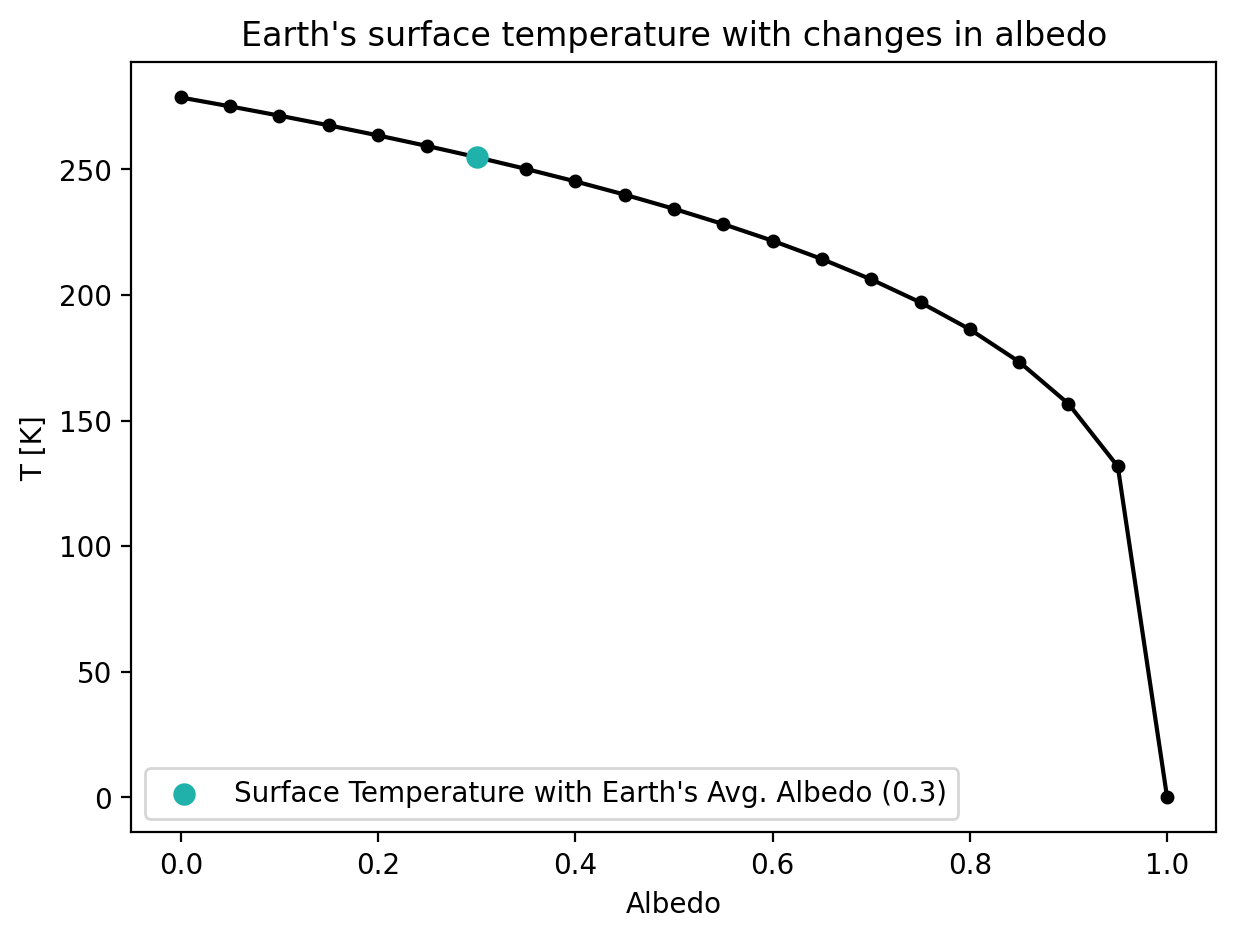

In [48]:
fig, ax = plt.subplots(figsize = (7, 5))

### add the Earth's surface temperature from the original model to the plot first:
ax.plot(seq_alpha, 
        earth_surface_temp(albedo = seq_alpha),
        marker='o', markersize = 4,
        color='k')

# Add a vertical dotted line from the x-axis up to the temperature at Earth's albedo
#ax.vlines(alpha, ymin=0, ymax=T_earth, color='paleturquoise', linestyle='--', linewidth=1)
#ax.hlines(T_earth, xmin=0, xmax=alpha, color='paleturquoise', linestyle='--', linewidth=1)

# Highlight Earth's temperature average albedo with a different colored point
ax.scatter(alpha,T_earth, color='lightseagreen', 
           zorder=2, # Controls the drawing order of elements in a plot
           label=f"Surface Temperature with Earth's Avg. Albedo ({alpha})", #Add a label for the highlighted point and adds the value of the parameter 'alpha'
           marker='o',s=50) #Marker size

## add plot title:
ax.set_title("Earth's surface temperature with changes in albedo")

## add axes labes:
ax.set_ylabel('T [K]')
ax.set_xlabel('Albedo')

ax.legend(loc="lower left")

Figure 3. Earth’s surface temperature with varying albedo values. The temperature corresponding to Earth's average albedo (0.3) is highlighted as a blue dot.

We can see that with albedo values closer to 1, which correspond to high reflectivity, the Earth's temperature would be lower. If the albedo were equal to 1, the temperature would reach absolute zero (0 K). The opposite occurs with albedo values closer to 0, where we observe higher temperatures, reaching a maximum when the albedo is 0 (278.68 K). 

In [52]:
print(np.round(earth_surface_temp(albedo = 0),2), "K")

278.68 K


> The absolute zero is the temperature at which a thermodynamic system has the lowest energy. It corresponds to 0 K (−273.15 °or −459.67 °F).
> 
> Source: https://www.britannica.com/science/absolute-zero

These results demonstrate the relationship between reflected energy and temperature in our simplified energy budget model. This helps us understand how real changes in albedo could have a direct impact on Earth’s temperature.

When considering the planet as a whole, the combined albedo of all surfaces yields the global average of 0.3 (Wielicki et al., 2005). The Earth has diverse environments and therefore, different abilities to reflect the energy from the Sun. Surfaces with high albedos, like sea ice, reflect most of the sunlight, while those with low albedos, such as dense, dark forests and deep oceans, absorb more solar energy (Table 1). Overall, global albedo varies with changes in Earth’s cloud cover, aerosol amount, forest cover (land), or snow and ice cover (Wielicki et al., 2005).

| | |
| --- | --- |
| If sea ice melts, the area with high reflectivity decreases, leading to more absorbed solar energy and a rise in the Earth’s average temperature. A similar process occurs with land ice, resulting in less reflected energy in those regions.  | ![sea ice image]( https://www.meereisportal.de/fileadmin/user_upload/Infografiken/Meereisphysik/Meereis_und_Strahlungsbilanz/Englisch/Ice-Albedo_Effect.png)Source: https://www.meereisportal.de/en/learn-more/sea-ice-for-beginners |
| Deforestation leads to increases in albedo because the exposed land or grasses reflect more sunlight than forests. This process may increase reflection, but the cooling effect from evaporative processes is reduced, and cloud formation decreases, leading to a lower cloud albedo. | ![deforestation albedo](https://cdn.mos.cms.futurecdn.net/qTBSNecxSPCZypfgvVznZT.jpg) source: https://www.livescience.com/66120-amazon-rainforest-deforestation-bolsonaro.html |
|  Volcano eruptions emit a considerable number of aerosols to the atmosphere that can be related to increasing the albedo of the planet. | ![Image]( https://www.thoughtco.com/thmb/WHiZnXQRhkHntE80etD9fjPv4N4=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/eruption-of-mt--pinatubo-NA009065-5c43fb0c46e0fb0001faf5fd.jpg) Source: Rosenberg, Matt. "The Mount Pinatubo Eruption in the Philippines." ThoughtCo, Apr. 5, 2023, thoughtco.com/mount-pinatubo-eruption-1434951. |

> An example of this was the **volcanic eruption of Mount Pinatubo** in the Philippines on  June 15, 1991, which caused a 2-year change in albedo due to the emission of stratospheric aerosols. This emissions of sulfur dioxide increased global albedo by up to 0.007 and decrease in worldwide temperature over the following years (Wielicki et al., 2005).

> **Clouds** act as a barrier by reflecting some of the Sun's radiation back into space, reducing the amount of heat absorbed by the surface.
>
> Source: https://greenly.earth/en-us/blog/ecology-news/what-is-the-albedo-effect-and-how-does-it-impact-global-warming

### <span style = "color: red">9</span>

### Evaluating the Earth's temperature with changes in atmospheric emissivity ($ \epsilon $)

As we did with albedo, we can also evaluate the **role of emissivity** in the energy budget model by assuming the other input parameters to be constant ($S_0$ and albedo). From the Stefan Boltzmann’s law, we know that the emissivity of an object, which ranges from 0 to 1, is a measure of how effective a material is at emitting thermal radiation. We can create a sequence from 0 to 1 to evaluate the temperature for each emissivity value.

In [53]:
seq_epsilon = np.arange(0,1.01,0.05) #Creates a sequence with epsilon values ranging from 0 to 1 by 0.1
seq_epsilon

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [54]:
earth_surface_temp(emissivity = seq_epsilon)

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_2108\34604045.py:19: RuntimeWarning: divide by zero encountered in divide
  temp_earth = ( ((1- albedo)*S0)/(4*emissivity*sigma) ) ** 0.25


array([         inf, 539.05536361, 453.28972288, 409.59350181,
       381.16970305, 360.48804826, 344.42570739, 331.40485133,
       320.52423689, 311.22375929, 303.13310752, 295.99556256,
       289.62634266, 283.88832576, 278.67715148, 273.91168332,
       269.52768181, 265.47347903, 261.70694353, 258.19330182,
       254.90354346])

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_2108\34604045.py:19: RuntimeWarning: divide by zero encountered in divide
  temp_earth = ( ((1- albedo)*S0)/(4*emissivity*sigma) ) ** 0.25


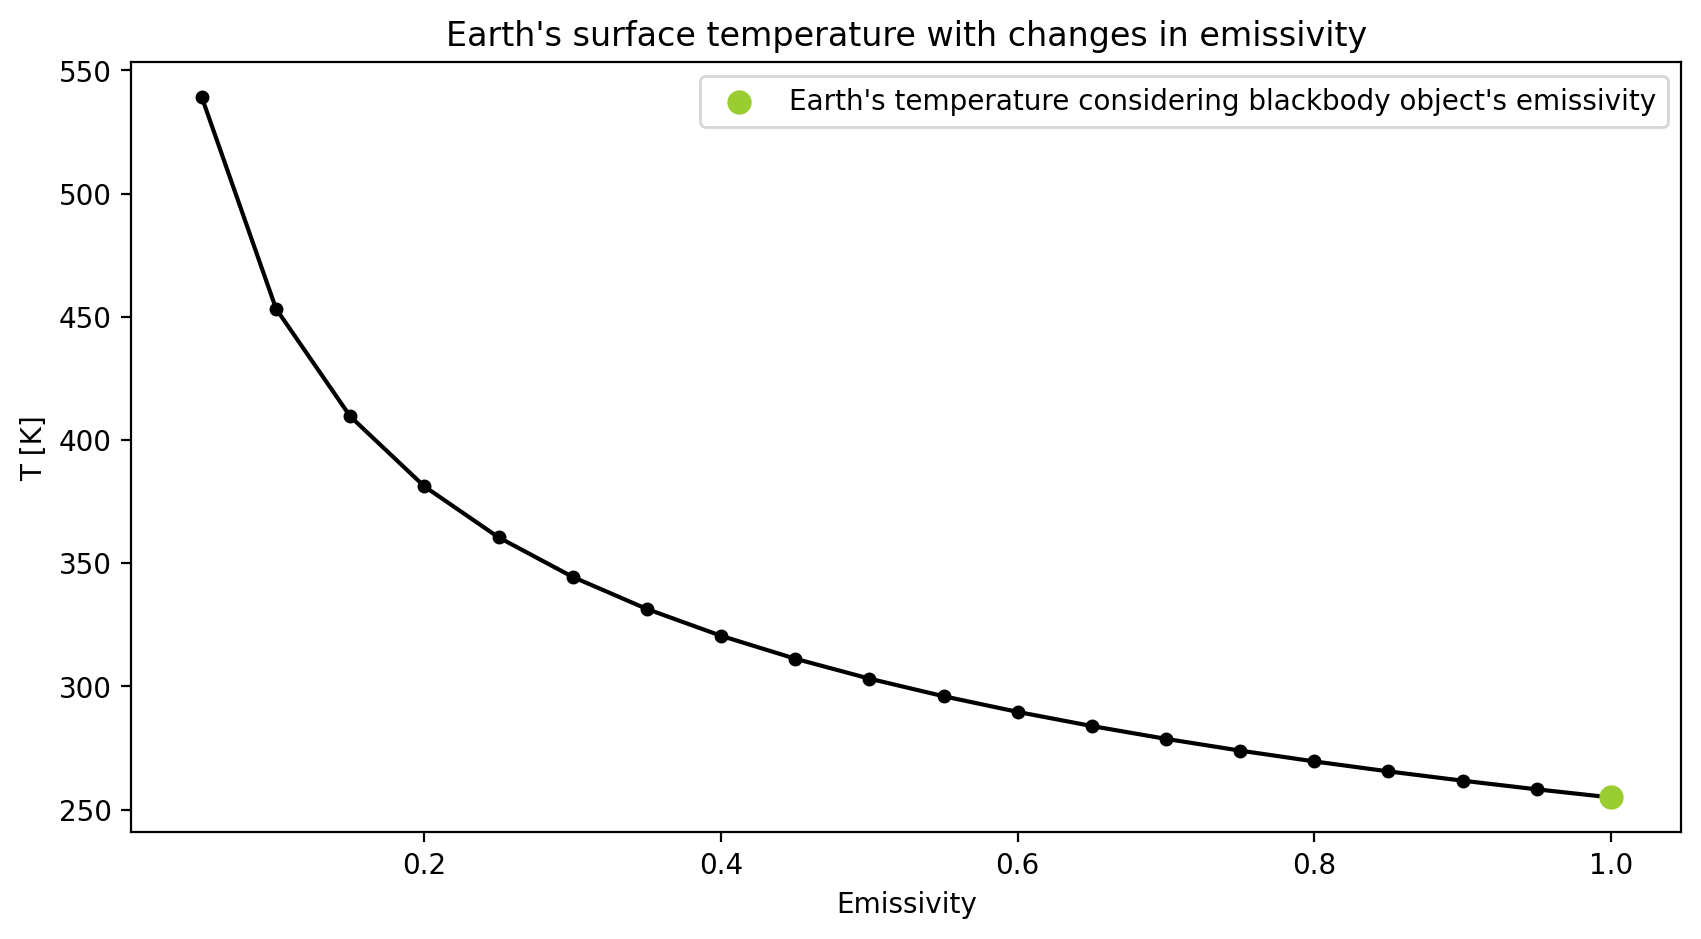

In [59]:
fig, ax = plt.subplots(figsize = (10, 5))

### add the Earth's surface temperature from the original model to the plot first:
ax.plot(seq_epsilon, 
        earth_surface_temp(emissivity = seq_epsilon),
        marker='o', markersize = 4,
        color='k')

# Highlight Earth's temperature average albedo with a different colored point
ax.scatter(epsilon,T_earth, color='yellowgreen', 
           zorder=2, # Controls the drawing order of elements in a plot
           label="Earth's temperature considering blackbody object's emissivity", #Add a label for the highlighted point
           marker='o',s=60) #Marker size

## add plot title:
ax.set_title("Earth's surface temperature with changes in emissivity")

## add axes labes:
ax.set_ylabel('T [K]')
ax.set_xlabel('Emissivity')

ax.legend()

Figure 4. Earth’s surface temperature with changes in emissivity, with albedo and $S_0$ constant. The temperature corresponding to Earth's as a blackbody object (0.1) is highlighted as a green dot.

We can observe that when emissivity values are closer to 1, Earth’s temperature would be lower. Higher emissivity means an object is better at emitting heat or infrared radiation, effectively radiating energy more efficiently. In contrast, when emissivity values are closer to 0, temperatures are higher (278.68 K). 

Source: https://terra.nasa.gov/news/aster-global-emissivity-database-100-times-more-detailed-than-its-predecessors

In [62]:
print(np.round(earth_surface_temp(albedo = 0.000001),2), "K")

278.68 K


![emissivity](https://journals.ametsoc.org/view/journals/clim/31/9/full-jcli-d-17-0125.1-f1.jpg) 

Source: (Huang et al., 2018)


Emissivity depends on the surface and varies with wavelength (as seen in the image above). The emissivity of most natural Earth surfaces is a unitless quantity and ranges between approximately 0.6 and 1.0, but surfaces with emissivity less than 0.85 are typically restricted to deserts and semi-arid areas. Vegetation, water and ice have high emissivity, above 0.95 in the thermal infrared wavelength range but dry grass can have between 0.75 and 0.95 emissivity (Huang et al., 2018). Therefore, any change in surface properties, atmospheric composition or cloud cover(van Wijngaarden & Happer, 2024) can affect Earth's emissivity, altering how efficiently the planet radiates heat into space.

* Melting ice or snow changes the surface to water or land, which can have lower emissivity, thus affecting how much heat is radiated.  
* Gases like carbon dioxide, methane, and water vapor absorb and re-emit infrared radiation. A change in their concentrations can alter the emissivity of the atmosphere by trapping more heat and reducing the amount emitted directly from the surface.  
* Dust, soot, volcanic ash, and other particles in the atmosphere can change the emissivity by absorbing and scattering radiation. This can either increase or decrease the overall emissivity depending on the type of particles.


### <span style = "color: red">10</span>

### So far, we have seen how changes in albedo, emissivity and solar irradiance influence the Earth’s surface temperature in a simple approach that excludes the atmosphere and greenhouse gases. However, the atmosphere’s effect is powerful, as the  <span style = "color: red">presence of GHG</span> warms the planet increasing the globally averaged temperature from -18.25°C to a much more habitable 15°C. However, perturbations on the climate system may cause imbalances in the Earth’s energy budget. A climate forcing [$W/{m}^2$] is an imposed change of the planetary energy balance.(Hansen et al., 2005). Common examples of forcing agents are shown in Figure 5.

![image](https://www.calacademy.org/sites/default/files/styles/manual_crop_standard_960x540/public/uploads/images/earthenergybalance-fullpicture1200x900.png?itok=4v__oLBW&c=4874a7bbdf86685ab5d0739c7f1896c1)

<center> source: https://www.calacademy.org/educators/earths-delicate-energy-balance </center>

In [63]:
#Load data
temp_NASA = pd.read_csv(ees_climate_dir+'unit2_grisales/data/model_results/NASA_GISS_Response_To_Forcings.csv')#,parse_dates=['Date'])
temp_observed = pd.read_csv(ees_climate_dir+'unit2_grisales/data/model_results/Observed_Temps.csv')#,parse_dates=['Date'])


In [64]:
temp_NASA.head(5)

,Year,All forcings,Human,Natural,Anthropogenic tropospheric aerosol,Greenhouse gases,Land use,Orbital changes,Ozone,Solar,Volcanic
0,1850,287.467659,287.428996,287.446649,287.425891,287.417000,287.450350,287.442937,287.450645,287.450350,287.446649
1,1851,287.517853,287.433725,287.460201,287.446402,287.399260,287.394453,287.450825,287.407646,287.434744,287.458259
2,1852,287.517558,287.473824,287.530642,287.498657,287.415606,287.482750,287.453118,287.447467,287.466309,287.560542
3,1853,287.478262,287.454695,287.519732,287.417325,287.433217,287.509894,287.468205,287.475366,287.455296,287.534299
4,1854,287.477572,287.417804,287.507810,287.424542,287.420589,287.445774,287.486590,287.454192,287.436233,287.552440


In [65]:
temp_observed.head(5)

,Year,Annual_Mean,5-year_Mean
0,1880,-0.23,NaN
1,1881,-0.15,NaN
2,1882,-0.18,-0.21
3,1883,-0.21,-0.22
4,1884,-0.29,-0.24


In [66]:
temp_NASA['Year'].min(),temp_NASA['Year'].max()

(1850, 2005)

In [68]:
temp_observed['Year'].min(),temp_observed['Year'].max()

(1880, 2014)

Text(0.5, 0, 'Year')

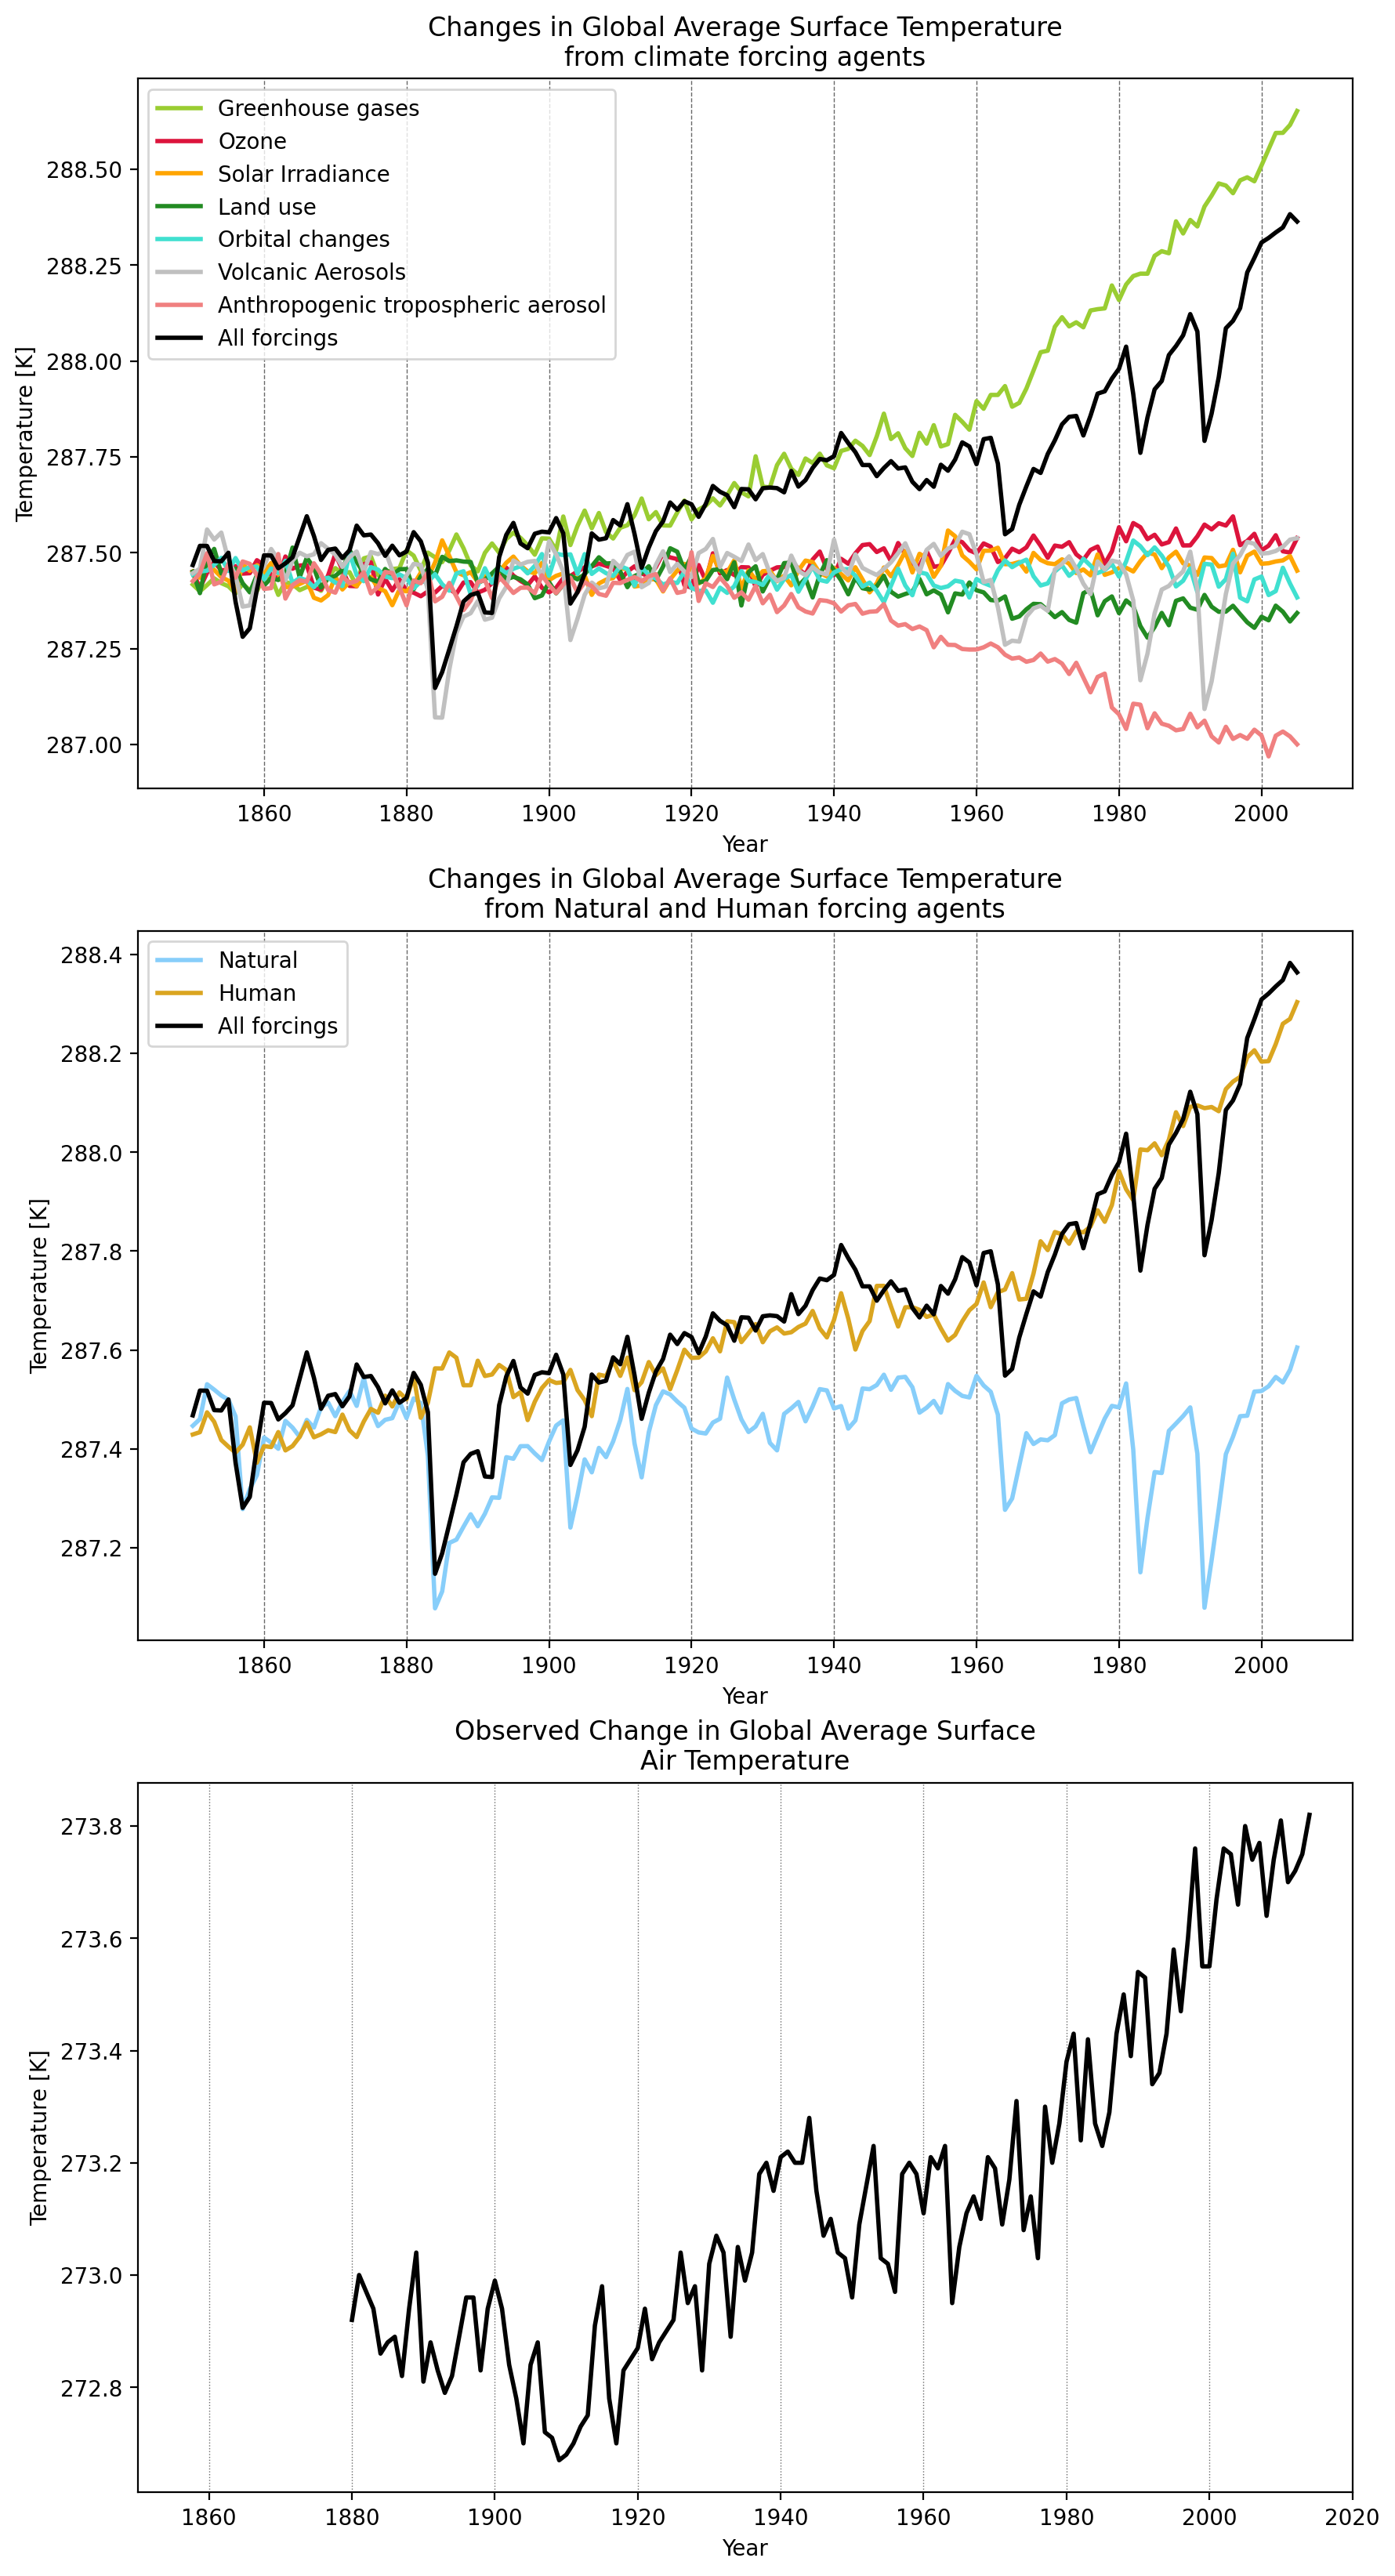

In [67]:
fig, (ax, ax2, ax3) = plt.subplots(nrows = 3, ncols = 1, figsize = (10,20))



ax.plot(temp_NASA['Year'],
        temp_NASA['Greenhouse gases'],
        linewidth=2,label='Greenhouse gases',
        color='yellowgreen')#limegreen')

ax.plot(temp_NASA['Year'],
        temp_NASA['Ozone'],
        linewidth=2,label='Ozone',
        color='crimson')

ax.plot(temp_NASA['Year'],
        temp_NASA['Solar'],
        linewidth=2,label='Solar Irradiance',
        color='orange')

ax.plot(temp_NASA['Year'],
        temp_NASA['Land use'],
        linewidth=2,label='Land use',#linestyle=':',
        color='forestgreen')

ax.plot(temp_NASA['Year'],
        temp_NASA['Orbital changes'],
        linewidth=2,label='Orbital changes',
        color='turquoise')

ax.plot(temp_NASA['Year'],
        temp_NASA['Volcanic'],
        linewidth=2,label='Volcanic Aerosols',
        color='silver')

ax.plot(temp_NASA['Year'],
        temp_NASA['Anthropogenic tropospheric aerosol'],
        linewidth=2,label='Anthropogenic tropospheric aerosol',
        color='lightcoral')

ax.plot(temp_NASA['Year'],
        temp_NASA['All forcings'],
        linewidth=2,label='All forcings',
        color='black')


## plot a legend on the ax
ax.legend() 

## add plot title:
ax.set_title('Changes in Global Average Surface Temperature\n\
from climate forcing agents')

## add axes labes:
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Year')

#Add vertical grid 
ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

#### Axis2: Temperature from Natural and Human forcing agents

### add the Natural forcings
ax2.plot(temp_NASA['Year'],
        temp_NASA['Natural'],
        linewidth=2,label='Natural',
        color='lightskyblue')

### add the human forcings
ax2.plot(temp_NASA['Year'],
        temp_NASA['Human'],
        linewidth=2,label='Human',
        color='goldenrod')

ax2.plot(temp_NASA['Year'],
        temp_NASA['All forcings'],
        linewidth=2,label='All forcings',
        color='black')

#Add vertical grid 
ax2.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

## plot a legend on the ax
ax2.legend() 

## add plot title:
ax2.set_title('Changes in Global Average Surface Temperature\n\
from Natural and Human forcing agents')

## add axes labes:
ax2.set_ylabel('Temperature [K]')
ax2.set_xlabel('Year')

#### Axis 3: Changes in observed temperature 

### add the human forcings
ax3.plot(temp_observed['Year'],
        temp_observed['Annual_Mean']+273.15,
        linewidth=2,
        color='black')

#Set x-axis limits
ax3.set_xlim([temp_NASA['Year'].min(),2020])#,temp_observed['Year'].max()])

#Add vertical grid 
ax3.grid(True,axis='x',linestyle=':', linewidth=0.5, color = 'dimgray')
## add plot title:
ax3.set_title("Observed Change in Global Average Surface\n\
Air Temperature")

## add axes labes:
ax3.set_ylabel('Temperature [K]')
ax3.set_xlabel('Year')


Figure 5. Change in global average surface air temperature from individual climate forcing agents (top), combined natural and human forcing agents (second) from 1850 to 2005, and observed change in global average surface air temperature from 1880 to 2014 (bottom). Dataset from NASA GISS ModelE2 developed as NASA’s Goddard Institute for Space Studies.

### <span style = "color: red">11</span>

When evaluating each individual forcing agent, we can observe that the solar fluctuations hasn’t changed much since the 1850; land use changes from forest to grasslands reflect more of the sun’s light, has had a modest cooling effect; volcano eruptions show cooling of the Earth for a year or two when they erupt (as mentioned previously with the aftermath of Mount Pinatubo’s eruption); anthropogenic aerosols reduce warming, as they reflect more of the sun’s energy back to space; tropospheric ozone increases the temperature a bit; however, rising concentrations of greenhouse gases, as the result of human activity, are by far the biggest cause.


When comparing all forcings to observed changes in temperature, we notice a clear positive trend between the combined effect of human activities and temperature changes. Moreover, the combination of all radiative forcings closely matches long-term changes in observed temperatures, supporting the hypothesis that global temperature changes are strongly associated with human activities.

## Effects of forcing agents from a simple energy budget perspective:

We can explain the effects of individual forcings in Earth’s surface temperature in terms of the concepts we evaluated in our simple energy budget model:

**Greenhouse Gases:** carbon dioxide, methane, and water vapor absorb and emit infrared radiation, which reduces the overall emissivity of the Earth system. This means less heat is radiated back into space, leading to higher surface temperatures.

**Aerosols:** Depending on the type, aerosols can increase albedo by scattering sunlight back to space, cooling the surface. However, some aerosols, specifically Short-Lived Climate Forcers (SLCF) like black carbon, which is a fraction of fine particulate matter ($PM_2.5$) associated to incomplete combustion of fossil fuels and biomass, reduce albedo by absorbing solar energy and warming the atmosphere. Aerosols can also affect cloud formation, changing the cloud albedo and, in turn, Earth's reflectivity.

**Land use changes:** Changes in land cover alter the surface albedo. These changes can either warm or cool the surface depending on how albedo and emissivity are affected by the specific land use change.

**Tropospheric ozone:** Ozone in the troposphere is a SLCF, which absorbs heat and reduce the emissivity of Earth's surface and lower atmosphere (IPCC, 2023). This means more heat is retained, contributing to temperature increments. Increases in ozone are directly attributable to human emissions of these gases (Zeke Hausfather, 2017).

**Volcanic Eruptions:** Volcanic aerosols cause short-term cooling of the Earth's surface by increasing albedo.

**Solar Activity:** Variations in solar irradiance directly affect Earth’s surface temperature by altering the amount of incoming energy, although these changes are generally small compared to other forcings. However, we can observe in Figure 5 that, over the past 50 years, solar irradiance has declined slightly, while Earth’s temperature have increased dramatically (Zeke Hausfather, 2017).



## <span style = "color: red">Conclusions</span>

* The Sun is the primary source of Earth's energy, and changes in solar irradiance directly impact Earth’s temperature. The historical Total Solar Irradiance (TSI) reconstruction shows that solar energy has varied over time, influencing temperature variations. However, these variations are small and insufficient to account for recent temperature changes without considering other factors.

* Albedo and emissivity are key parameters in Earth's energy balance. Albedo dictates how much solar radiation is reflected into space, with surfaces like snow and ice having high albedo and contributing to cooling. Emissivity, the efficiency of Earth's surface in emitting thermal radiation, also influences temperature. Higher emissivity leads to more efficient heat radiation and cooler surface temperatures, while lower emissivity reduces heat loss and warms the surface.

* Based on an energy balance model, we can understand in a simplified matter the effects different forcing agents produce in the Earth system, as they can be related to changes in albedo or emissivity. Natural factors like volcanic eruptions, changes in solar activity, and variations in surface albedo from ice and vegetation can cause short-term climate fluctuations. However, when comparing individual forcings to observed long-term temperature changes, human activities, particularly greenhouse gas emissions, have a significantly larger and consistent warming effect. This is evident when combining all radiative forcings, as the model results closely match the observed warming trend.

* The combination of natural and human-induced forcings demonstrates that only models including human factors like greenhouse gases and aerosols match the observed global temperature trends. This strongly supports the hypothesis that human activities are the primary driver of recent global warming.

### References:

Coddington, O., Lean, J. L., Pilewskie, P., Snow, M., & Lindholm, D. (2016). A solar irradiance climate data record. Bulletin of the American Meteorological Society, 97(7), 1265–1282. https://doi.org/10.1175/BAMS-D-14-00265.1

Hansen, J., Sato, M., Ruedy, R., Nazarenko, L., Lacis, A., Schmidt, G. A., Russell, G., Aleinov, I., Bauer, M., Bauer, S., Bell, N., Cairns, B., Canuto, V., Chandler, M., Cheng, Y., Del Genio, A., Faluvegi, G., Fleming, E., Friend, A., … Zhang, S. (2005). Efficacy of climate forcings. In Journal of Geophysical Research D: Atmospheres (Vol. 110, Issue 18, pp. 1–45). https://doi.org/10.1029/2005JD005776

Huang, X., Chen, X., Flanner, M., Yang, P., Feldman, D., & Kuo, C. (2018). Improved representation of surface spectral emissivity in a global climate model and its impact on simulated climate. Journal of Climate, 31(9), 3711–3727. https://doi.org/10.1175/JCLI-D-17-0125.1

IPCC. (2023). Short-lived Climate Forcers. In Climate Change 2021 – The Physical Science Basis (pp. 817–922). Cambridge University Press. https://doi.org/10.1017/9781009157896.008

Kopp, G., Krivova, N., Wu, • C J, & Lean, J. (2016). The Impact of the Revised Sunspot Record on Solar Irradiance Reconstructions. 1. https://doi.org/10.1007/s11207-016-0853

Kostrykin, S., Revokatova, A., Chernenkov, A., Ginzburg, V., Polumieva, P., & Zelenova, M. (2021). Black carbon emissions from the siberian fires 2019: Modelling of the atmospheric transport and possible impact on the radiation balance in the arctic region. Atmosphere, 12(7). https://doi.org/10.3390/atmos12070814

van Wijngaarden, W. A., & Happer, W. (2024). Effect of Greenhouse Gases on Thermal Emissivity by Clouds. http://arxiv.org/abs/2401.03061

Wielicki, B. A., Wong, T., Loeb, N., Minnis, P., Priestley, K., & Kandel, R. (2005). Changes in earth’s albedo measured by satellite. Science, 308(5723), 825. https://doi.org/10.1126/science.1106484

Zeke Hausfather. (2017, December 13). Analysis: Why scientists think 100% of global warming is due to humans. https://www.carbonbrief.org/analysis-why-scientists-think-100-of-global-warming-is-due-to-humans/


